# Treinar Modelo com Dataset Aumentado

Este notebook treina um NOVO modelo usando o dataset aumentado.

**⚠️ IMPORTANTE:**
- NÃO sobrescreve o modelo original (best_model_fe.h5)
- Salva como: best_model_fe_AUGMENTED.h5
- Compara automaticamente com o modelo original (70.14%)

**📋 Pré-requisito:**
Execute primeiro: `python safe_augmentation_test.py`

## 1. Imports

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path
import os

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: []


## 2. Verificar Dataset Aumentado

In [2]:
AUGMENTED_CSV = 'labels_augmented_TEST.csv'
AUGMENTED_FOLDER = 'dataset_augmented_TEST'
ORIGINAL_CSV = 'labels.csv'

print("="*60)
print("🔍 VERIFICANDO ARQUIVOS")
print("="*60)

if not os.path.exists(AUGMENTED_CSV):
    print("❌ ERRO: Dataset aumentado não encontrado!")
    print("\n🔧 Execute primeiro:")
    print("   source venv/bin/activate")
    print("   python safe_augmentation_test.py")
    print("\nDepois volte e execute este notebook.")
    raise FileNotFoundError(f"{AUGMENTED_CSV} não encontrado")

print("✅ Dataset aumentado encontrado!")
print(f"   CSV: {AUGMENTED_CSV}")
print(f"   Pasta: {AUGMENTED_FOLDER}")

# Carregar dados
df_original = pd.read_csv(ORIGINAL_CSV)
df_aug = pd.read_csv(AUGMENTED_CSV)

print(f"\n📊 COMPARAÇÃO DE DATASETS")
print(f"   Original: {len(df_original)} imagens")
print(f"   Aumentado: {len(df_aug)} imagens")
print(f"   Sintéticas: +{len(df_aug) - len(df_original)}")

print(f"\n📈 Distribuição no dataset aumentado:")
print(df_aug['bristol_type'].value_counts().sort_index())

🔍 VERIFICANDO ARQUIVOS
✅ Dataset aumentado encontrado!
   CSV: labels_augmented_TEST.csv
   Pasta: dataset_augmented_TEST

📊 COMPARAÇÃO DE DATASETS
   Original: 211 imagens
   Aumentado: 301 imagens
   Sintéticas: +90

📈 Distribuição no dataset aumentado:
bristol_type
1    31
2    42
3    57
4    73
5    35
6    37
7    26
Name: count, dtype: int64


## 3. Preparar Dados

In [3]:
# Configurações
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Converter para string
df_aug['bristol_type_str'] = df_aug['bristol_type'].astype(str)

# Split estratificado
train_df_aug, test_df_aug = train_test_split(
    df_aug,
    test_size=0.2,
    stratify=df_aug['bristol_type'],
    random_state=42
)

print(f"✅ Dados preparados!")
print(f"   Train: {len(train_df_aug)} imagens")
print(f"   Test: {len(test_df_aug)} imagens")

print(f"\n📊 Distribuição Train:")
print(train_df_aug['bristol_type'].value_counts().sort_index())

✅ Dados preparados!
   Train: 240 imagens
   Test: 61 imagens

📊 Distribuição Train:
bristol_type
1    25
2    33
3    45
4    58
5    28
6    30
7    21
Name: count, dtype: int64


## 4. Criar Geradores de Dados

In [4]:
# Data Augmentation
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen_aug = ImageDataGenerator(rescale=1./255)

# Criar geradores
train_generator_aug = train_datagen_aug.flow_from_dataframe(
    train_df_aug,
    x_col='filename',
    y_col='bristol_type_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42,
    subset='training'
)

val_generator_aug = train_datagen_aug.flow_from_dataframe(
    train_df_aug,
    x_col='filename',
    y_col='bristol_type_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

test_generator_aug = test_datagen_aug.flow_from_dataframe(
    test_df_aug,
    x_col='filename',
    y_col='bristol_type_str',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("✅ Geradores criados!")
print(f"   Train: {train_generator_aug.samples} imagens")
print(f"   Validation: {val_generator_aug.samples} imagens")
print(f"   Test: {test_generator_aug.samples} imagens")

Found 192 validated image filenames belonging to 7 classes.
Found 48 validated image filenames belonging to 7 classes.
Found 61 validated image filenames belonging to 7 classes.
✅ Geradores criados!
   Train: 192 imagens
   Validation: 48 imagens
   Test: 61 imagens


## 5. Criar Modelo

In [5]:
def create_feature_extraction_model():
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )
    
    base_model.trainable = False
    
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(7, activation='softmax')
    ])
    
    return model

print("🏗️ Criando modelo...")
model_fe_aug = create_feature_extraction_model()

model_fe_aug.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Modelo criado!")
print("\n⚠️ IMPORTANTE:")
print("   - Será salvo como: best_model_fe_AUGMENTED.h5")
print("   - NÃO sobrescreve: best_model_fe.h5 (70.14%)")

model_fe_aug.summary()

🏗️ Criando modelo...
✅ Modelo criado!

⚠️ IMPORTANTE:
   - Será salvo como: best_model_fe_AUGMENTED.h5
   - NÃO sobrescreve: best_model_fe.h5 (70.14%)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,113,543 (57.65 MB)

 Trainable params: 397,319 (1.52 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

## 6. Calcular Class Weights

In [6]:
y_train_aug = train_df_aug['bristol_type'].values

class_weights_aug = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_aug),
    y=y_train_aug
)

class_weight_dict_aug = dict(enumerate(class_weights_aug))

print("✅ Class Weights:")
for i, weight in class_weight_dict_aug.items():
    count = len(train_df_aug[train_df_aug['bristol_type'] == i+1])
    print(f"  Tipo {i+1}: {weight:.2f} (n={count})")

✅ Class Weights:
  Tipo 1: 1.37 (n=25)
  Tipo 2: 1.04 (n=33)
  Tipo 3: 0.76 (n=45)
  Tipo 4: 0.59 (n=58)
  Tipo 5: 1.22 (n=28)
  Tipo 6: 1.14 (n=30)
  Tipo 7: 1.63 (n=21)


## 7. Configurar Callbacks

In [7]:
callbacks_aug = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model_fe_AUGMENTED.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("✅ Callbacks configurados")

✅ Callbacks configurados


## 8. TREINAR Modelo

In [8]:
print("="*60)
print("🚀 INICIANDO TREINAMENTO COM DATASET AUMENTADO")
print("="*60)
print("\n⏱️ Tempo estimado: 10-20 minutos na CPU")
print("☕ Hora de pegar um café!\n")

history_fe_aug = model_fe_aug.fit(
    train_generator_aug,
    validation_data=val_generator_aug,
    epochs=50,
    callbacks=callbacks_aug,
    class_weight=class_weight_dict_aug,
    verbose=1
)

print("\n" + "="*60)
print("✅ TREINAMENTO COMPLETO!")
print("="*60)

🚀 INICIANDO TREINAMENTO COM DATASET AUMENTADO

⏱️ Tempo estimado: 10-20 minutos na CPU
☕ Hora de pegar um café!

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2861 - loss: 2.4777
Epoch 1: val_accuracy improved from None to 0.29167, saving model to best_model_fe_AUGMENTED.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.3177 - loss: 2.4626 - val_accuracy: 0.2917 - val_loss: 1.8301 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3864 - loss: 2.0073
Epoch 2: val_accuracy improved from 0.29167 to 0.35417, saving model to best_model_fe_AUGMENTED.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.4479 - loss: 1.8929 - val_accuracy: 0.3542 - val_loss: 1.7780 - learning_rate: 0.0010
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4310 - loss: 1.8260
Epoch 3: val_accuracy did not improve from 0.35417
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.4844 - loss: 1.6112 - val_accuracy: 0.3125 - val_loss: 1.7544 - learning_rate: 0.0010
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5037 - loss: 1.4690
Epoch 4: val_accuracy did not improve from 0.35417
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.5208 - loss: 1.5128 - val_accuracy: 0.2500 - val_loss: 1.7270 - learning_rate: 0.0010
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6463 - loss: 1.2562
Epoch 5: val_accuracy did not improve from 0.35417
12/12 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.6094 - loss: 1.3558 - val_accuracy: 0.2708 - val_loss: 1.6912 - learning_rate: 0.0010
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2

12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.6250 - loss: 1.0604 - val_accuracy: 0.4375 - val_loss: 1.6292 - learning_rate: 0.0010
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6519 - loss: 1.0505
Epoch 11: val_accuracy did not improve from 0.43750
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.6510 - loss: 1.1519 - val_accuracy: 0.2917 - val_loss: 1.6722 - learning_rate: 0.0010
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6802 - loss: 1.0111
Epoch 12: val_accuracy did not improve from 0.43750
12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.6719 - loss: 1.0685 - val_accuracy: 0.3750 - val_loss: 1.6106 - learning_rate: 0.0010
Epoch 13/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6000 - loss: 1.2332
Epoch 13: val_accuracy did not improve from 0.43750
12/12 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.6302 - loss: 1.1893 - val_accuracy: 0.4167 - val_loss: 1.5855 - learning_rate: 0.0010
Epoch 14/50
12/12 ━━━━━━━━━━━━━━━━━━

12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6406 - loss: 0.9927 - val_accuracy: 0.4583 - val_loss: 1.4788 - learning_rate: 0.0010
Epoch 15/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6750 - loss: 0.9502
Epoch 15: val_accuracy improved from 0.45833 to 0.47917, saving model to best_model_fe_AUGMENTED.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6458 - loss: 1.0207 - val_accuracy: 0.4792 - val_loss: 1.4799 - learning_rate: 0.0010
Epoch 16/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6818 - loss: 0.9472
Epoch 16: val_accuracy improved from 0.47917 to 0.56250, saving model to best_model_fe_AUGMENTED.h5


12/12 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.6771 - loss: 1.0203 - val_accuracy: 0.5625 - val_loss: 1.4159 - learning_rate: 0.0010
Epoch 17/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6482 - loss: 0.9344
Epoch 17: val_accuracy did not improve from 0.56250
12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6458 - loss: 0.9573 - val_accuracy: 0.4375 - val_loss: 1.4964 - learning_rate: 0.0010
Epoch 18/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6653 - loss: 0.9825
Epoch 18: val_accuracy did not improve from 0.56250
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.6875 - loss: 0.9184 - val_accuracy: 0.5000 - val_loss: 1.4482 - learning_rate: 0.0010
Epoch 19/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6905 - loss: 0.9973
Epoch 19: val_accuracy did not improve from 0.56250
12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.6979 - loss: 0.8746 - val_accuracy: 0.4375 - val_loss: 1.4726 - learning_rate: 0.0010
Epoch 20/50
12/12 ━━━━━━━━━━━━━━━━━━

12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.7865 - loss: 0.6812 - val_accuracy: 0.5833 - val_loss: 1.4272 - learning_rate: 2.5000e-04
Epoch 42/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7842 - loss: 0.6832
Epoch 42: val_accuracy did not improve from 0.58333
12/12 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.7656 - loss: 0.6923 - val_accuracy: 0.4583 - val_loss: 1.4755 - learning_rate: 2.5000e-04
Epoch 43/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7222 - loss: 0.7790
Epoch 43: val_accuracy did not improve from 0.58333
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.7448 - loss: 0.7006 - val_accuracy: 0.4792 - val_loss: 1.4123 - learning_rate: 2.5000e-04
Epoch 44/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7979 - loss: 0.6504
Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 44: val_accuracy did not improve from 0.58333
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.8073 - loss: 0.5788 - val_accura

## 9. Visualizar Curvas de Aprendizado

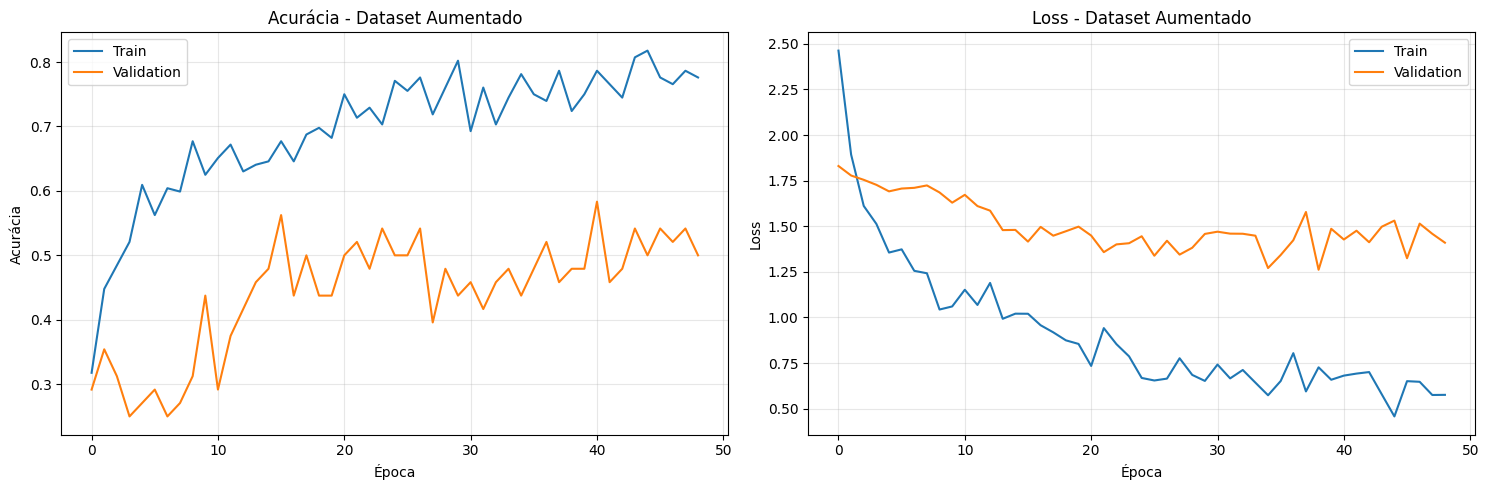

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
ax1.plot(history_fe_aug.history['accuracy'], label='Train')
ax1.plot(history_fe_aug.history['val_accuracy'], label='Validation')
ax1.set_title('Acurácia - Dataset Aumentado')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history_fe_aug.history['loss'], label='Train')
ax2.plot(history_fe_aug.history['val_loss'], label='Validation')
ax2.set_title('Loss - Dataset Aumentado')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. COMPARAR com Modelo Original

📊 COMPARAÇÃO FINAL

🔵 MODELO ORIGINAL
   Dataset: 211 imagens
   Acurácia: 0.7014 (70.14%)
   Loss: 1.0559

🟢 MODELO AUMENTADO
   Dataset: 301 imagens
   Acurácia: 0.4754 (47.54%)
   Loss: 1.4611

📈 DIFERENÇA:
   -0.2260 (-32.22%) ⚠️ PIOROU


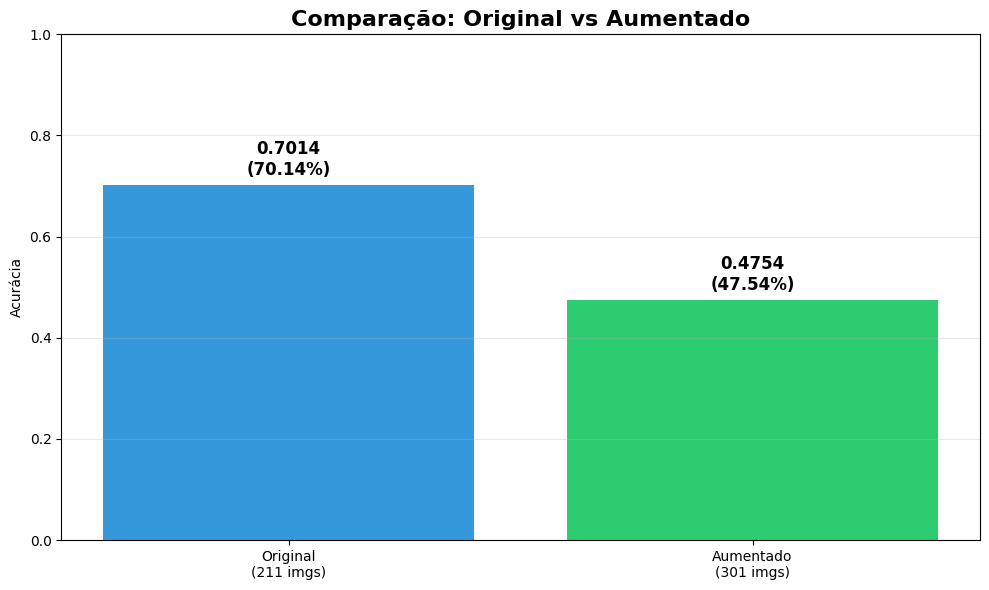


💡 RECOMENDAÇÃO

⚠️ Dataset aumentado NÃO melhorou

🔧 Sugestões:
   - Manter modelo original (70.14%)
   - Tentar augmentation diferente
   - Coletar mais dados reais



In [11]:
print("="*60)
print("📊 COMPARAÇÃO FINAL")
print("="*60)

# Avaliar modelo aumentado
test_loss_aug, test_acc_aug = model_fe_aug.evaluate(test_generator_aug, verbose=0)

# Modelo original (valores conhecidos)
test_acc_orig = 0.7014
test_loss_orig = 1.0559

print(f"\n🔵 MODELO ORIGINAL")
print(f"   Dataset: 211 imagens")
print(f"   Acurácia: {test_acc_orig:.4f} ({test_acc_orig*100:.2f}%)")
print(f"   Loss: {test_loss_orig:.4f}")

print(f"\n🟢 MODELO AUMENTADO")
print(f"   Dataset: {len(df_aug)} imagens")
print(f"   Acurácia: {test_acc_aug:.4f} ({test_acc_aug*100:.2f}%)")
print(f"   Loss: {test_loss_aug:.4f}")

# Calcular diferença
diff = test_acc_aug - test_acc_orig
diff_percent = (diff / test_acc_orig) * 100

print(f"\n📈 DIFERENÇA:")
if diff > 0:
    print(f"   +{diff:.4f} ({diff_percent:+.2f}%) 🎉 MELHOROU!")
elif diff < 0:
    print(f"   {diff:.4f} ({diff_percent:.2f}%) ⚠️ PIOROU")
else:
    print(f"   0.0000 (sem mudança)")

# Gráfico comparativo
comparison = pd.DataFrame({
    'Modelo': ['Original\n(211 imgs)', f'Aumentado\n({len(df_aug)} imgs)'],
    'Acurácia': [test_acc_orig, test_acc_aug]
})

plt.figure(figsize=(10, 6))
bars = plt.bar(comparison['Modelo'], comparison['Acurácia'], 
               color=['#3498db', '#2ecc71'])
plt.title('Comparação: Original vs Aumentado', fontsize=16, fontweight='bold')
plt.ylabel('Acurácia')
plt.ylim([0, 1])

for i, v in enumerate(comparison['Acurácia']):
    plt.text(i, v + 0.02, f'{v:.4f}\n({v*100:.2f}%)', 
            ha='center', fontweight='bold', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Recomendação
print("\n" + "="*60)
print("💡 RECOMENDAÇÃO")
print("="*60)

if diff > 0.03:
    print("\n✅ Dataset aumentado MELHOROU significativamente!")
    print(f"   Ganho: +{diff*100:.2f}%")
    print("\n🎯 Próximos passos:")
    print("   1. Usar modelo: best_model_fe_AUGMENTED.h5")
    print("   2. Considerar usar dataset aumentado")
elif diff > 0:
    print("\n✅ Dataset aumentado melhorou levemente")
    print(f"   Ganho: +{diff*100:.2f}%")
    print("\n💭 Considere testar mais configurações")
else:
    print("\n⚠️ Dataset aumentado NÃO melhorou")
    print("\n🔧 Sugestões:")
    print("   - Manter modelo original (70.14%)")
    print("   - Tentar augmentation diferente")
    print("   - Coletar mais dados reais")

print("\n" + "="*60)